# Lab 4 — Data Quality Assessment & Pre‑processing

This notebook cleans and prepares the sales dataset for analysis and machine learning.

We will:
- inspect data quality
- handle missing values
- detect outliers
- normalize features
- apply PCA

## 1️. Load Dataset
This step imports libraries and loads the dataset.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("GoogleAds_DataAnalytics_Sales_Uncleaned.csv")
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,2024-11-22,hyderabad,desktop,online data analytic


## 2️. Inspect Data
We check structure, data types, and basic info.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ad_ID            2600 non-null   object 
 1   Campaign_Name    2600 non-null   object 
 2   Clicks           2488 non-null   float64
 3   Impressions      2546 non-null   float64
 4   Cost             2503 non-null   object 
 5   Leads            2552 non-null   float64
 6   Conversions      2526 non-null   float64
 7   Conversion Rate  1974 non-null   float64
 8   Sale_Amount      2461 non-null   object 
 9   Ad_Date          2600 non-null   object 
 10  Location         2600 non-null   object 
 11  Device           2600 non-null   object 
 12  Keyword          2600 non-null   object 
dtypes: float64(5), object(8)
memory usage: 264.2+ KB


Check summary statistics to understand distributions and possible anomalies.

In [11]:
df.describe()

,Clicks,Impressions,Leads,Conversions,Conversion Rate
count,2488.000000,2546.000000,2552.000000,2526.000000,1974.000000
mean,138.956994,4523.280833,20.003918,6.519002,0.048979
std,34.619376,869.927913,6.032317,2.272573,0.019987
min,80.000000,3000.000000,10.000000,3.000000,0.015000
25%,110.000000,3764.000000,15.000000,5.000000,0.035000
50%,139.000000,4518.500000,20.000000,7.000000,0.046000
75%,169.000000,5279.500000,25.000000,9.000000,0.058000
max,199.000000,5999.000000,30.000000,10.000000,0.123000


## 3️. Check Missing Values
Missing values can cause errors and affect analysis.

In [12]:
df.isna().sum()

,0
Ad_ID,0
Campaign_Name,0
Clicks,112
Impressions,54
Cost,97
Leads,48
Conversions,74
Conversion Rate,626
Sale_Amount,139
Ad_Date,0


### Handling Missing Values
We replace missing numerical values using **median** because it is robust to extreme values.

In [13]:
df['Sale_Amount'] = df['Sale_Amount'].str.replace('$','', regex=False)
df['Sale_Amount'] = pd.to_numeric(df['Sale_Amount'], errors='coerce')

df['Sale_Amount'].fillna(df['Sale_Amount'].median(), inplace=True)

/tmp/ipykernel_290/3296275169.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sale_Amount'].fillna(df['Sale_Amount'].median(), inplace=True)


## 4️. Convert Data Types
Convert columns to correct numeric and date formats.

In [14]:
df['Clicks'] = pd.to_numeric(df['Clicks'], errors='coerce')
df['Impressions'] = pd.to_numeric(df['Impressions'], errors='coerce')
df['Leads'] = pd.to_numeric(df['Leads'], errors='coerce')

df['Ad_Date'] = pd.to_datetime(df['Ad_Date'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Ad_ID            2600 non-null   object        
 1   Campaign_Name    2600 non-null   object        
 2   Clicks           2488 non-null   float64       
 3   Impressions      2546 non-null   float64       
 4   Cost             2503 non-null   object        
 5   Leads            2552 non-null   float64       
 6   Conversions      2526 non-null   float64       
 7   Conversion Rate  1974 non-null   float64       
 8   Sale_Amount      2600 non-null   float64       
 9   Ad_Date          893 non-null    datetime64[ns]
 10  Location         2600 non-null   object        
 11  Device           2600 non-null   object        
 12  Keyword          2600 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(6)
memory usage: 264.2+ KB


Fill remaining missing numeric values with median.

In [15]:
df.fillna(df.median(numeric_only=True), inplace=True)

## 5️. Detect Outliers
Outliers are extreme values that can distort analysis.

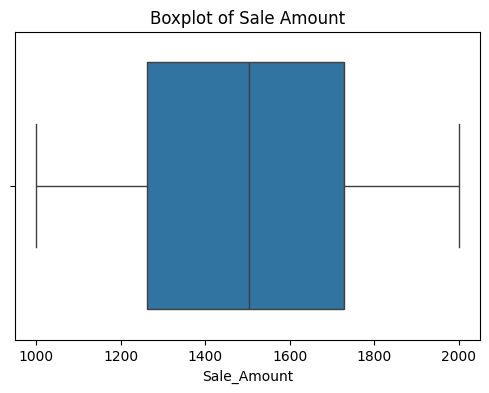

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Sale_Amount'])
plt.title("Boxplot of Sale Amount")
plt.show()

### Detect outliers using IQR method

In [17]:
Q1 = df['Sale_Amount'].quantile(0.25)
Q3 = df['Sale_Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Sale_Amount'] < lower) | (df['Sale_Amount'] > upper)]
outliers.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword


### Remove outliers to reduce distortion

In [18]:
df = df[(df['Sale_Amount'] >= lower) & (df['Sale_Amount'] <= upper)]
df.shape

(2600, 13)

## 6️. Normalize Numerical Features
Normalization scales features to a similar range.

In [19]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

num_cols = ['Sale_Amount','Clicks','Impressions','Leads']

# Min-Max Scaling
minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = minmax.fit_transform(df_minmax[num_cols])

df_minmax.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,0.201681,0.499500,$231.88,0.20,7.0,0.058,0.892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,0.781513,0.702568,$216.84,0.00,8.0,0.046,0.679,NaT,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,0.084034,0.514838,$203.66,0.80,9.0,0.046,0.624,NaT,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,0.521008,0.061687,$237.66,0.35,6.0,0.046,0.225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,0.638655,0.120373,$195.9,1.00,8.0,0.046,0.091,2024-11-22,hyderabad,desktop,online data analytic


### Z-score Standardization
Centers data around mean 0 and standard deviation 1.

In [20]:
scaler = StandardScaler()
df_zscore = df.copy()
df_zscore[num_cols] = scaler.fit_transform(df_zscore[num_cols])

df_zscore.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,-1.032492,-0.029258,$231.88,-1.004794,7.0,0.058,1.407267,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,1.005388,0.678324,$216.84,-1.674227,8.0,0.046,0.644574,NaT,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,-1.445975,0.024188,$203.66,1.003506,9.0,0.046,0.447634,NaT,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,0.089819,-1.554800,$237.66,-0.502719,6.0,0.046,-0.981073,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,0.503302,-1.350310,$195.9,1.672939,8.0,0.046,-1.460889,2024-11-22,hyderabad,desktop,online data analytic


## 7️. Correlation Check
We check relationships between numerical features.

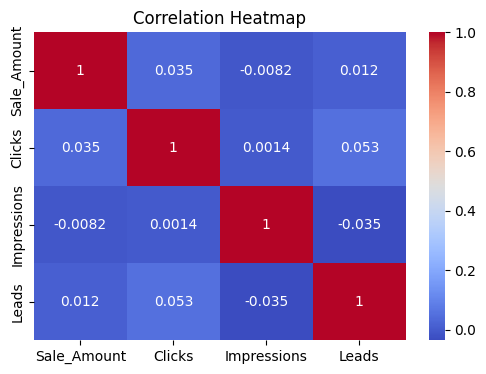

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 8️. Principal Component Analysis (PCA)
PCA reduces dimensionality while keeping important information.

In [22]:
from sklearn.decomposition import PCA

X = df_zscore[num_cols]

pca = PCA(n_components=2)
components = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.26916475 0.2519922 ]


### Visualize PCA Projection

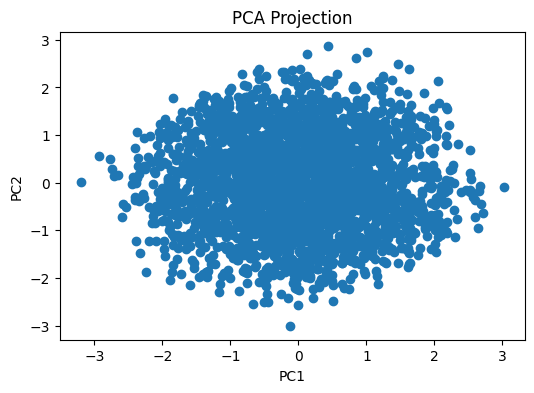

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(components[:,0], components[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

## Summary
In this notebook we:
- cleaned missing values
- corrected data types
- removed outliers
- normalized numerical features
- applied PCA for dimensionality reduction